In [1]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
# import warnings
# warnings.filterwarnings('ignore')

from keras.models import load_model
from keras.preprocessing import image
import numpy as np

c:\Users\Jeremy\Documents\Kuliah\ML-AI\nenv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
train_data_path = "facial/train"

filepaths = []
labels = []

folds = os.listdir(train_data_path)

for fold in folds:
  f_path = os.path.join(train_data_path, fold)
  if os.path.isdir(f_path):
    filelists = os.listdir(f_path)
    for file in filelists:
      filepaths.append(os.path.join(f_path, file))
      labels.append(fold)

Fseries = pd.Series(filepaths, name='Filepath')
Lseries = pd.Series(labels, name='Label')
train_df = pd.concat([Fseries, Lseries], axis=1)
train_df

,Filepath,Label
0,facial/train\angry\Training_10118481.jpg,angry
1,facial/train\angry\Training_10120469.jpg,angry
2,facial/train\angry\Training_10131352.jpg,angry
3,facial/train\angry\Training_10161559.jpg,angry
4,facial/train\angry\Training_1021836.jpg,angry
...,...,...
28703,facial/train\surprise\Training_99916297.jpg,surprise
28704,facial/train\surprise\Training_99924420.jpg,surprise
28705,facial/train\surprise\Training_99937001.jpg,surprise
28706,facial/train\surprise\Training_99951755.jpg,surprise


In [3]:
test_data_path = "facial/test"

filepaths = []
labels = []

folds = os.listdir(test_data_path)

for fold in folds:
  f_path = os.path.join(test_data_path, fold)
  if os.path.isdir(f_path):
    filelists = os.listdir(f_path)
    for file in filelists:
      filepaths.append(os.path.join(f_path, file))
      labels.append(fold)

Fseries = pd.Series(filepaths, name='Filepath')
Lseries = pd.Series(labels, name='Label')
test_df = pd.concat([Fseries, Lseries], axis=1)
test_df

,Filepath,Label
0,facial/test\angry\PrivateTest_10131363.jpg,angry
1,facial/test\angry\PrivateTest_10304478.jpg,angry
2,facial/test\angry\PrivateTest_1054527.jpg,angry
3,facial/test\angry\PrivateTest_10590091.jpg,angry
4,facial/test\angry\PrivateTest_1109992.jpg,angry
...,...,...
7173,facial/test\surprise\PublicTest_98089595.jpg,surprise
7174,facial/test\surprise\PublicTest_98567249.jpg,surprise
7175,facial/test\surprise\PublicTest_98972870.jpg,surprise
7176,facial/test\surprise\PublicTest_99242645.jpg,surprise


In [4]:
valid , test = train_test_split(test_df, train_size= 0.5, shuffle = True, random_state = 42)

In [5]:
img_size = (448 ,448)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'Filepath' , y_col = 'Label' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'Filepath' , y_col = 'Label' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'Filepath' , y_col = 'Label' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 28708 validated image filenames belonging to 7 classes.
Found 3589 validated image filenames belonging to 7 classes.
Found 3589 validated image filenames belonging to 7 classes.


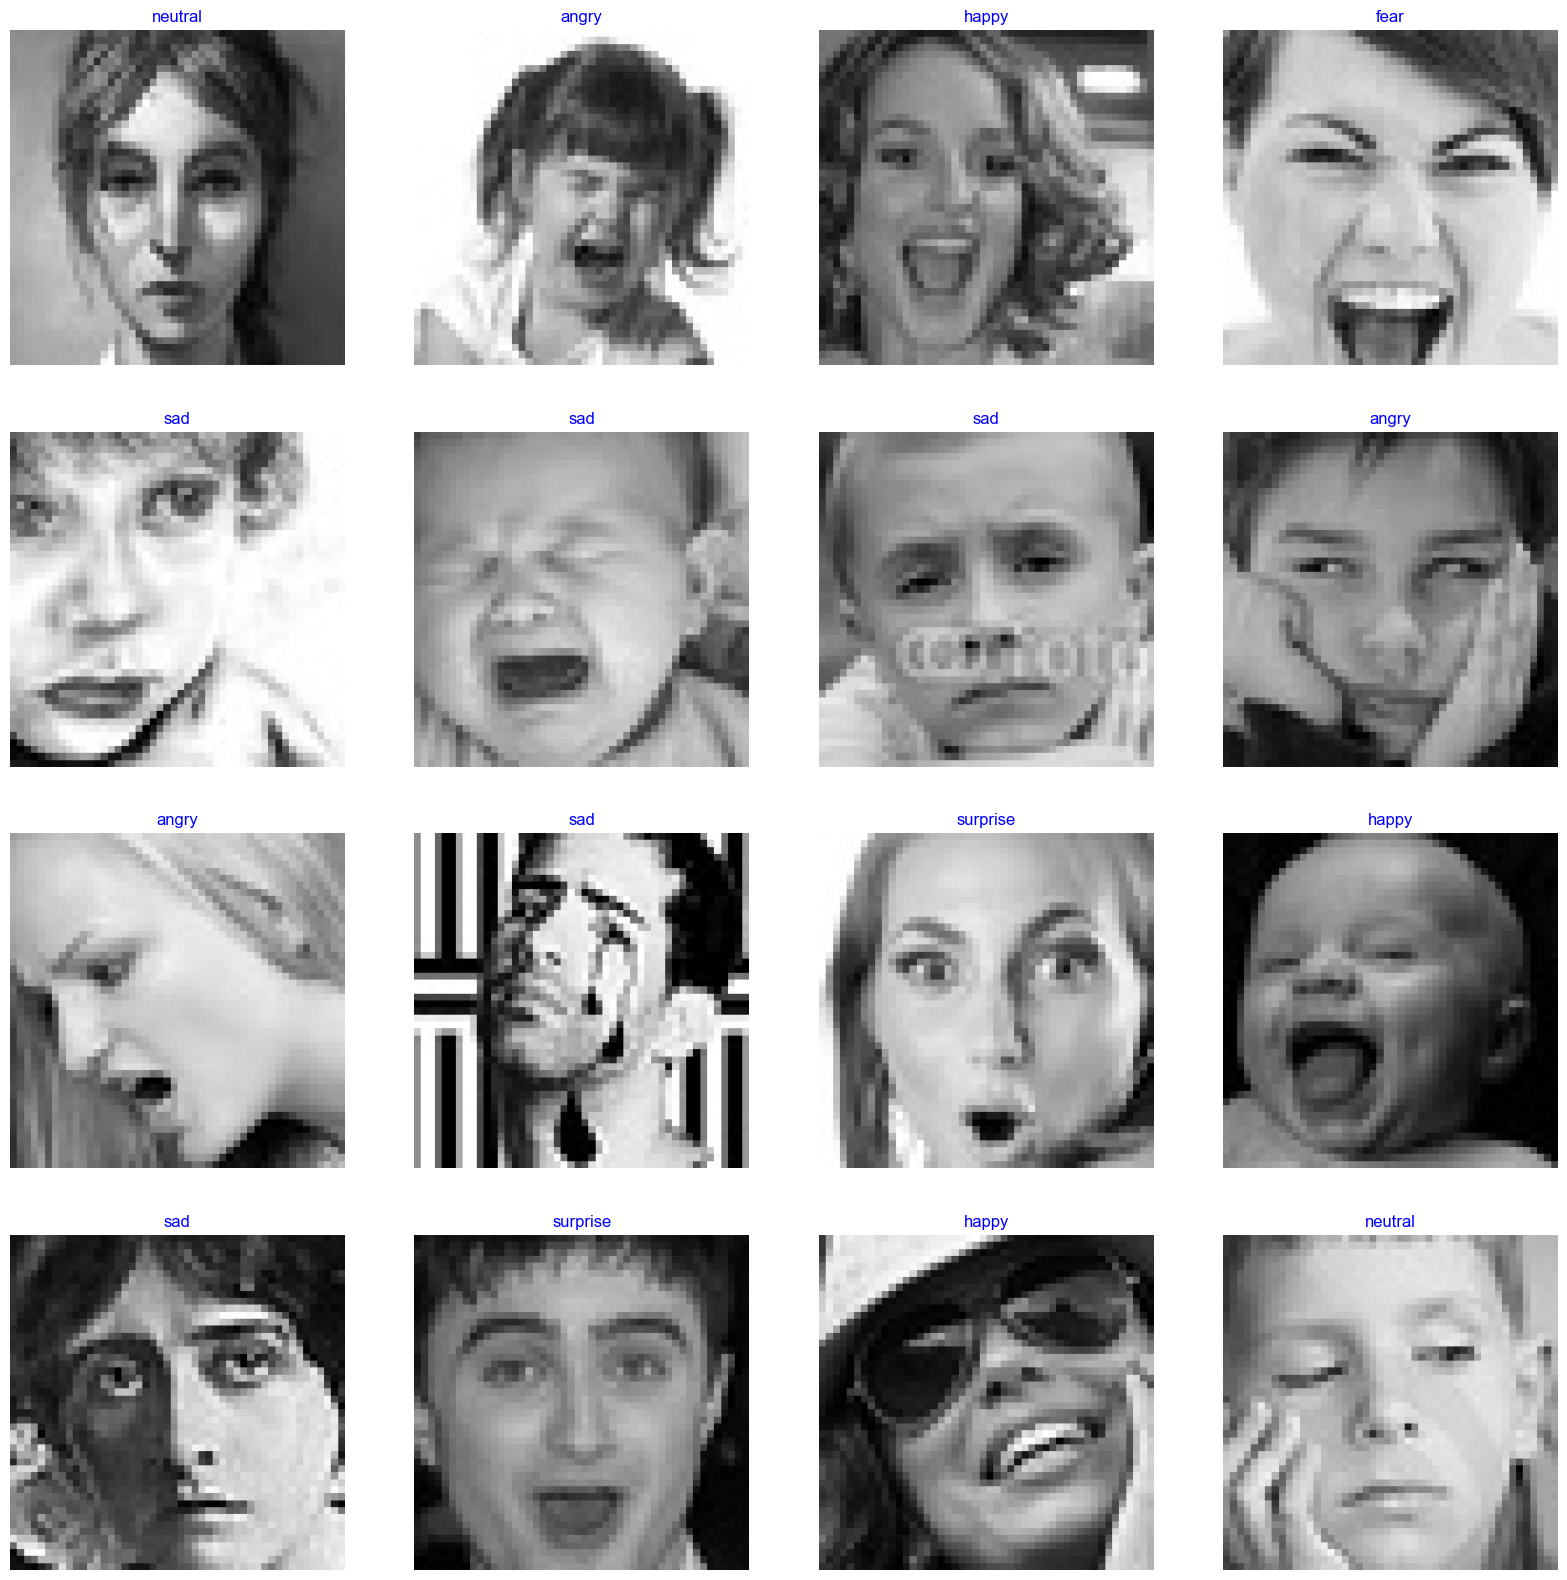

In [6]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize=(20,20))

for i in range(16):
  plt.subplot(4,4,i+1)
  image = images[i]/255
  plt.imshow(image)
  index = np.argmax(labels[i])
  class_name = classes[index]
  plt.title(class_name, color='blue', fontsize=12)
  plt.axis('off')
plt.show()

In [7]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'avg')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,254,167 (23.86 MB)

 Trainable params: 6,190,999 (23.62 MB)

 Non-trainable params: 63,168 (246.75 KB)

In [8]:
history = model.fit(
    train_gen,
    epochs = 5,
    verbose = 1,
    validation_data = valid_gen,
    shuffle = True
)

Epoch 1/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 12799s 7s/step - accuracy: 0.2472 - loss: 4.6501 - val_accuracy: 0.2466 - val_loss: 2.2967
Epoch 2/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 13047s 7s/step - accuracy: 0.2511 - loss: 1.9486 - val_accuracy: 0.2466 - val_loss: 1.8334
Epoch 3/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 12531s 7s/step - accuracy: 0.2512 - loss: 1.8196 - val_accuracy: 0.2469 - val_loss: 1.8233
Epoch 4/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 11790s 7s/step - accuracy: 0.2513 - loss: 1.8123 - val_accuracy: 0.2466 - val_loss: 1.8180
Epoch 5/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 13278s 7s/step - accuracy: 0.2513 - loss: 1.8112 - val_accuracy: 0.2466 - val_loss: 1.8171


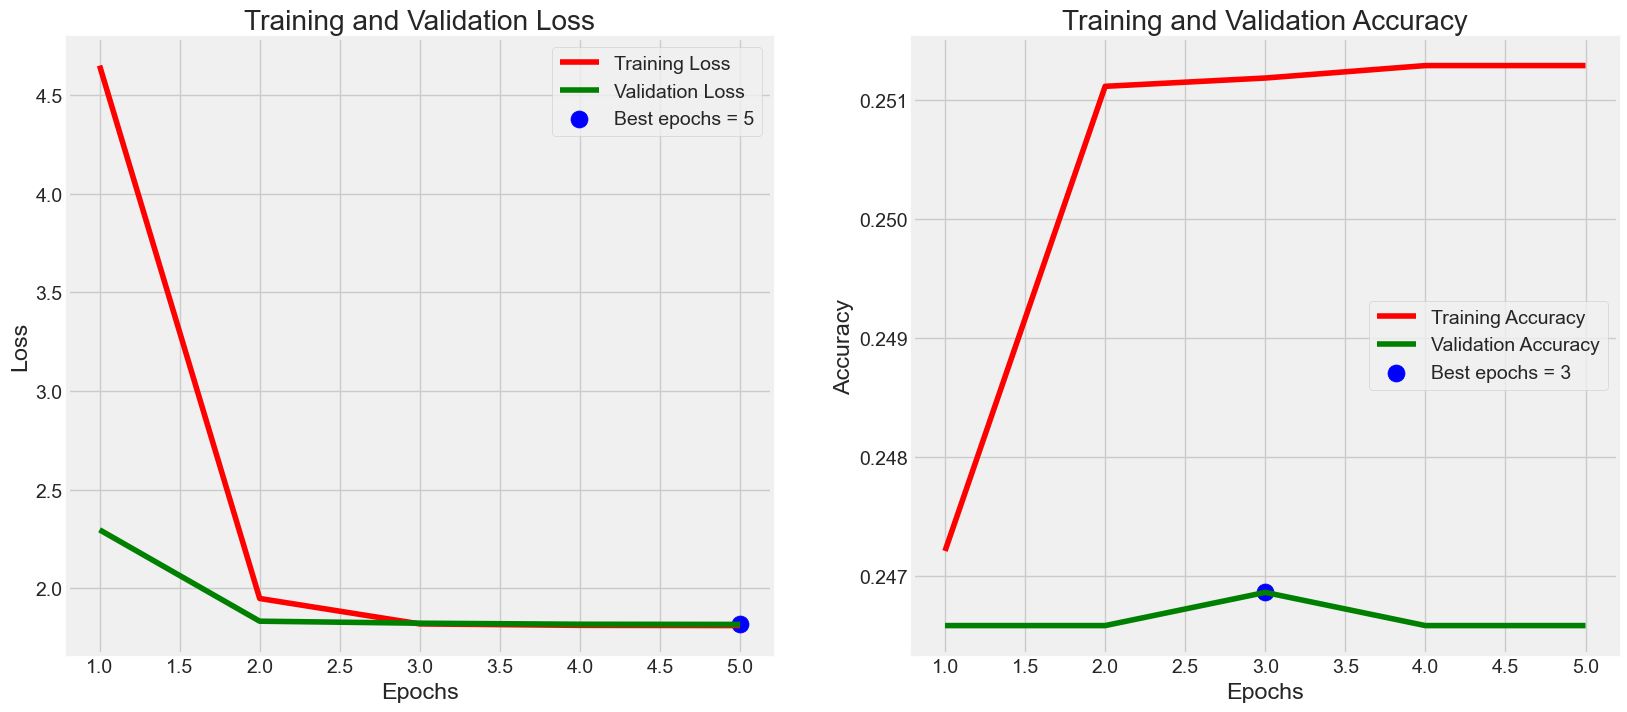

In [9]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show()

In [10]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2344 - loss: 1.8581
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2500 - loss: 1.7958
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2656 - loss: 1.8210
Train Loss:  1.8581175804138184
Train Accuracy:  0.234375
--------------------
Validation Loss:  1.7957721948623657
Validation Accuracy:  0.25
--------------------
Test Loss:  1.8210264444351196
Test Accuracy:  0.265625


In [11]:
preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 304s 1s/step


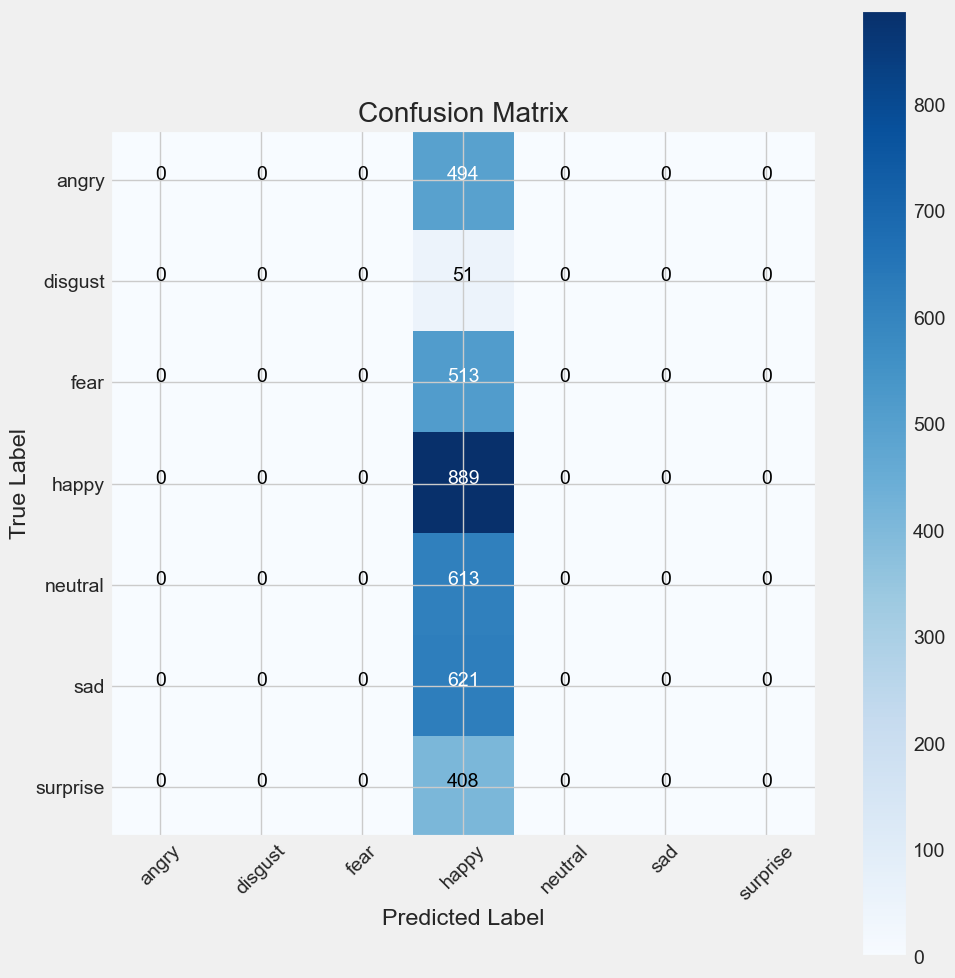

In [12]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [13]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       494
     disgust       0.00      0.00      0.00        51
        fear       0.00      0.00      0.00       513
       happy       0.25      1.00      0.40       889
     neutral       0.00      0.00      0.00       613
         sad       0.00      0.00      0.00       621
    surprise       0.00      0.00      0.00       408

    accuracy                           0.25      3589
   macro avg       0.04      0.14      0.06      3589
weighted avg       0.06      0.25      0.10      3589



c:\Users\Jeremy\Documents\Kuliah\ML-AI\nenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Jeremy\Documents\Kuliah\ML-AI\nenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Jeremy\Documents\Kuliah\ML-AI\nenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [14]:
model.save("facial.keras")

In [15]:
model = load_model('facial.keras', compile=False)
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [16]:
gambar = tf.keras.preprocessing.image.load_img('facial/test/angry/PrivateTest_88305.jpg', target_size=img_size)

input_arr = tf.keras.preprocessing.image.img_to_array(gambar)

input_arr = np.array([input_arr])
prediksi = model.predict(input_arr)
predicted_class = np.argmax(prediksi, axis=-1)

print(classes)
print(predicted_class)

names = [classes[i] for i in predicted_class]
print(names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
[3]
['happy']
